# 0 - Helpers

In [1]:
from generate_time_comparison import *

# 1 - Retrieve networks

In [ ]:
years = [2025, 2030, 2035, 2040]
#years = [2025, 2030]

# Main scenarios
scenarios_50 = ["baseline",
             "energy-match-50",
             #"hourly-match-50-90",
             #"hourly-match-50-95",
             #"hourly-match-50-98",
             #"hourly-match-50-99",
             ]


scenarios_25 = ["baseline",
             "energy-match-25",
             #"hourly-match-25-90",
             #"hourly-match-25-95",
             #"hourly-match-25-98",
             #"hourly-match-25-99",
             ]

# Load all networks
scenarios_all = {"main_CI_50": scenarios_50,
                 #"main_CI_25": scenarios_25,
                 }

df_networks_all = {}

for group, scenarios in scenarios_all.items():

    # Build MultiIndex
    index = pd.MultiIndex.from_product(
        [years, scenarios],
        names=["year", "scenario"]
    )

    # Create empty DataFrame
    df_networks = pd.DataFrame(index=index, columns=["network"])

    # Fill it
    for year, sc in index:
        try:
            n = pypsa.Network(f"../results/{sc}/networks/base_s_39___{year}.nc")
        except:
            print(f"{sc}-{year} not availabe")
            continue
        n = prepare_network(n)
        n.name = f"{sc}-{year}"
        df_networks.loc[(year, sc), "network"] = n

        m = strip_network_GoO(n)
        m.name = "GoO-" + m.name
        df_networks.loc[(year, sc), "GoO"] = m

    df_networks = df_networks.dropna()
    df_networks_all[group] = df_networks

# Calculate figsize automatically based on number of years
figsize_bar_resource_utilization = FIGSIZE_RESOURCE_UTILIZATION  # Fixed size for resource utilization bar plot
print(f"Using figsize for resource utilization bar plot: {figsize_bar_resource_utilization}")

INFO:pypsa.network.io:New version 1.0.5 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.5 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.5 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.5 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.5 available! (Current:

Using figsize for resource utilization bar plot: (12, 6)


# 1 - Resource utilization

/home/user/OET/projects/google-go-vs-gc/google-go/notebooks/generate_time_comparison.py:546: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/home/user/OET/projects/google-go-vs-gc/google-go/notebooks/generate_time_comparison.py:546: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/home/user/OET/projects/google-go-vs-gc/google-go/notebooks/generate_time_comparison.py:546: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

----------------------------------Analysing solar utility
------------------> Analysing scenario baseline


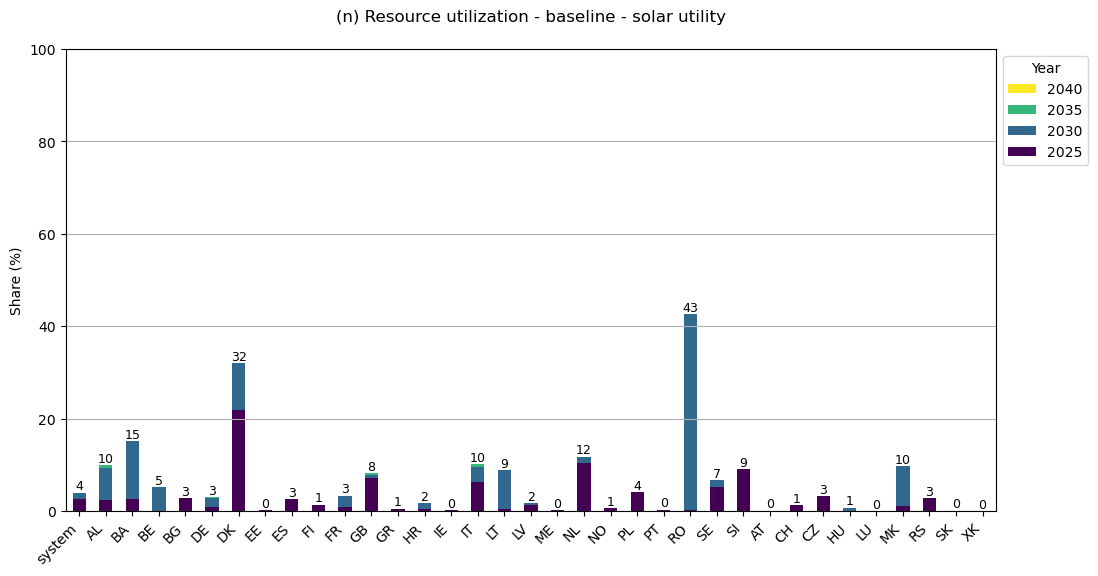

------------------> Analysing scenario energy-match-50


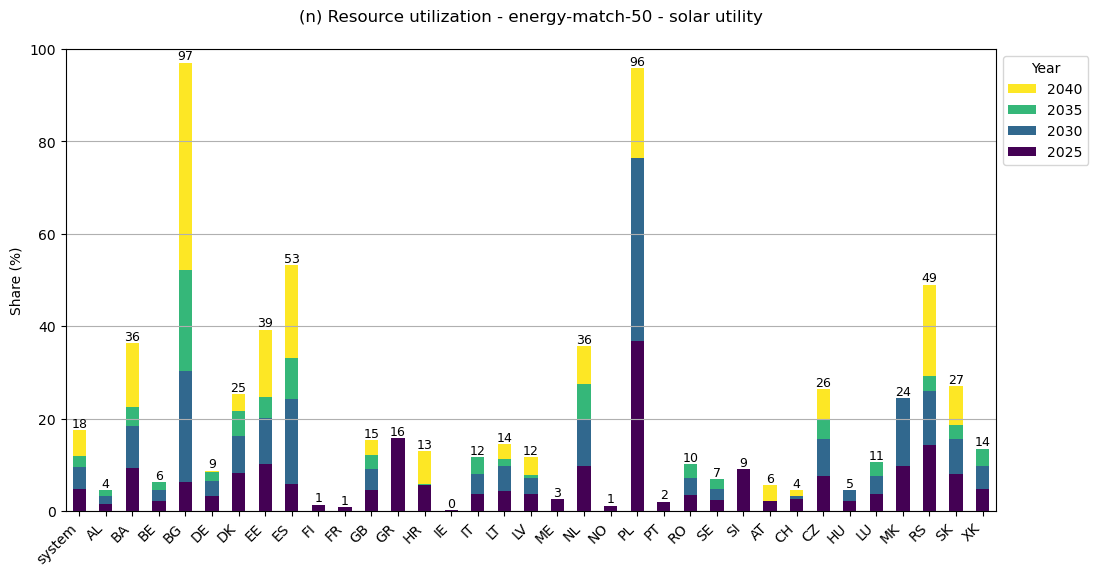

----------------------------------Analysing solar rooftop
------------------> Analysing scenario baseline


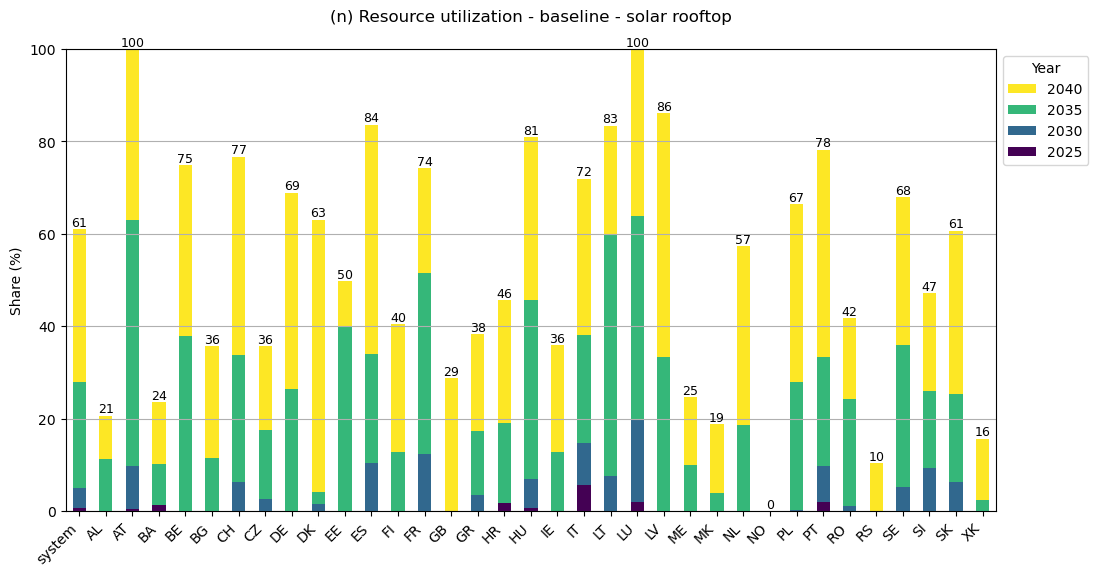

------------------> Analysing scenario energy-match-50


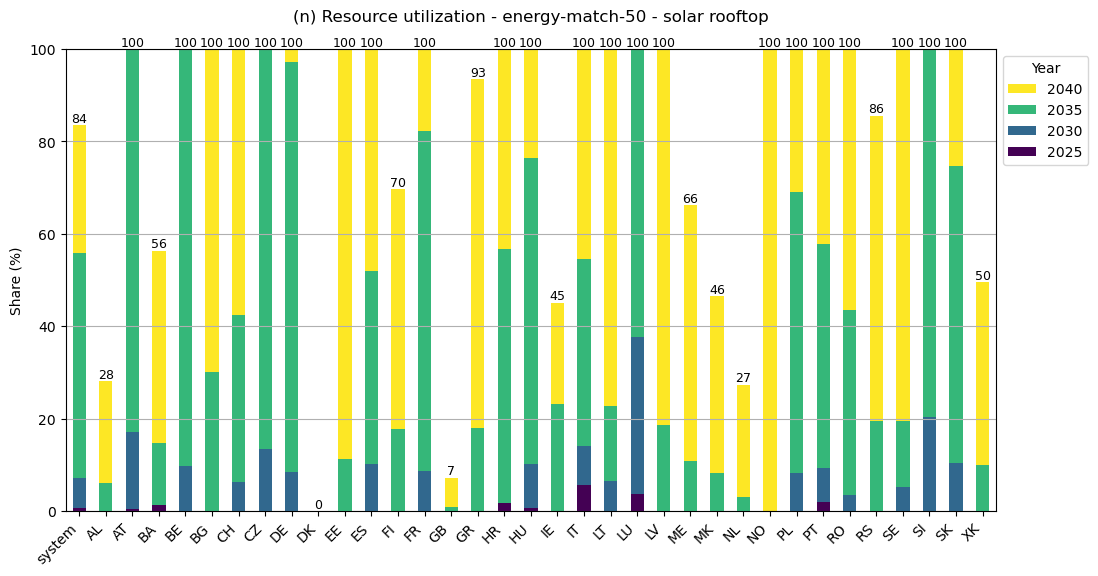

----------------------------------Analysing onwind
------------------> Analysing scenario baseline


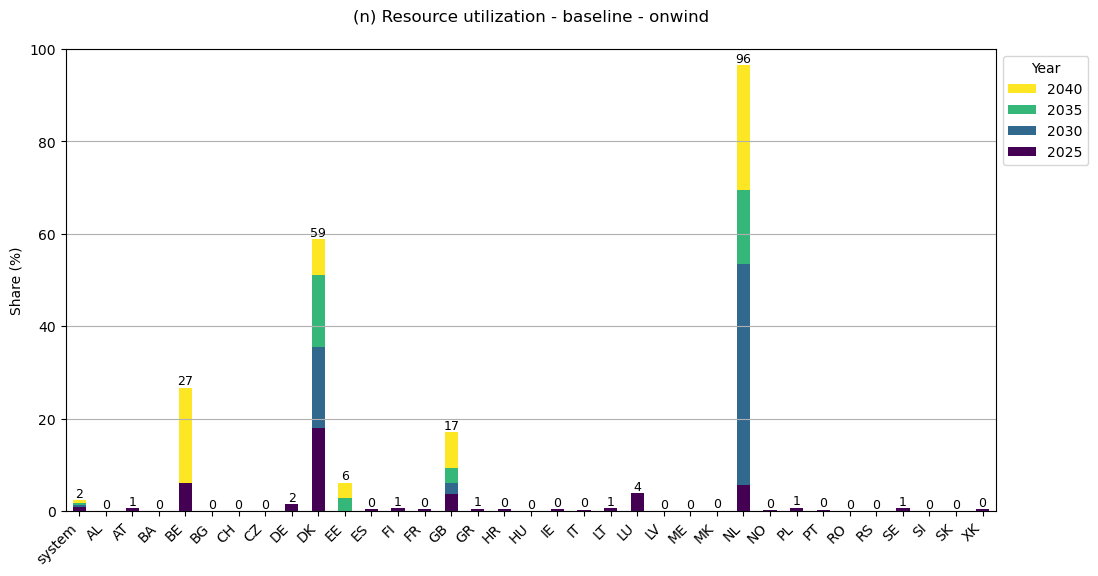

------------------> Analysing scenario energy-match-50


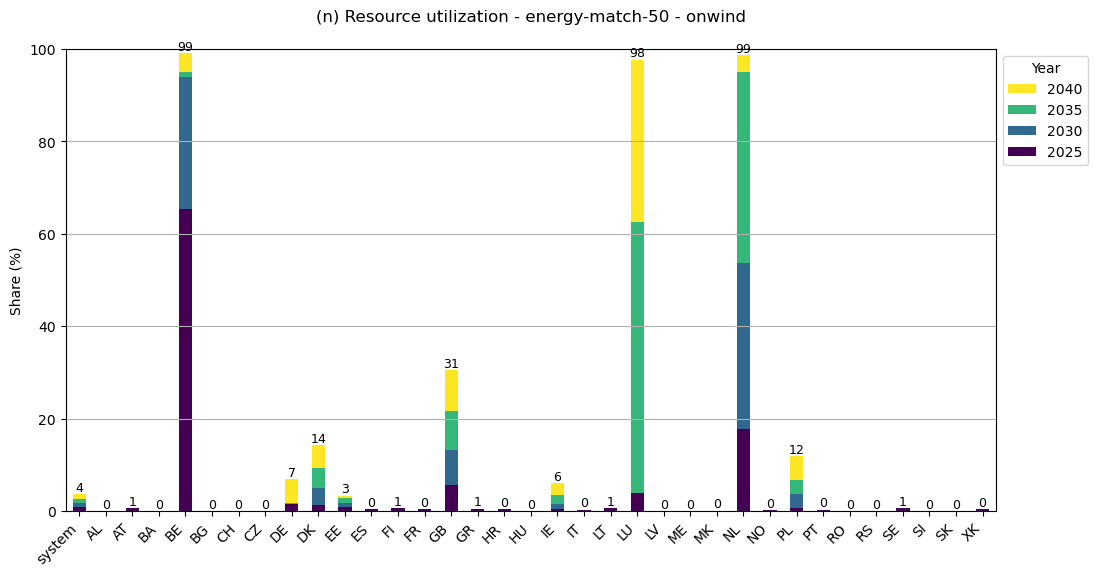

----------------------------------Analysing offwind-ac
------------------> Analysing scenario baseline


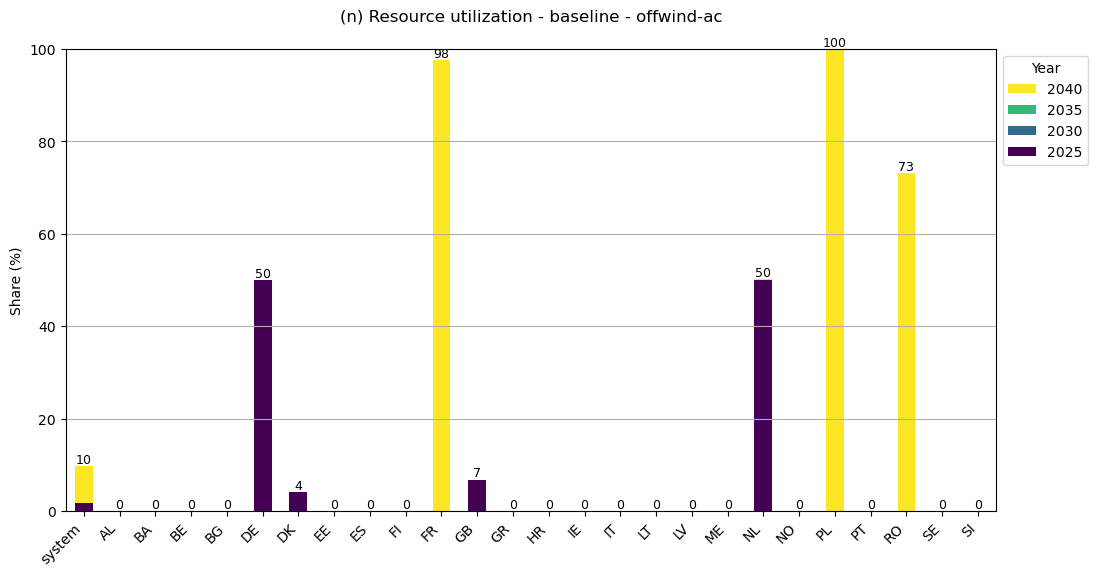

------------------> Analysing scenario energy-match-50


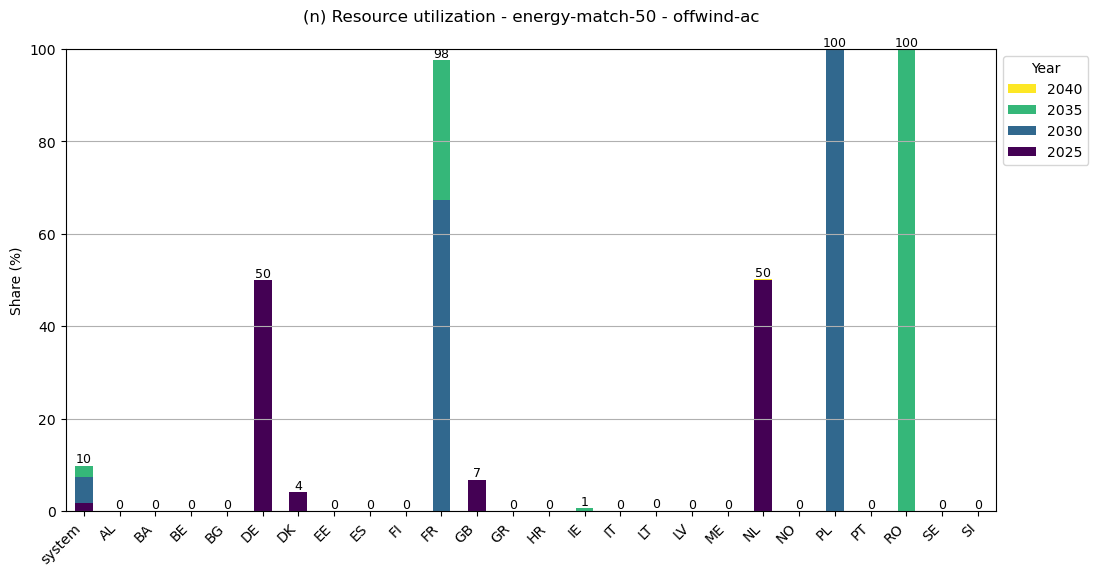

----------------------------------Analysing offwind-dc
------------------> Analysing scenario baseline


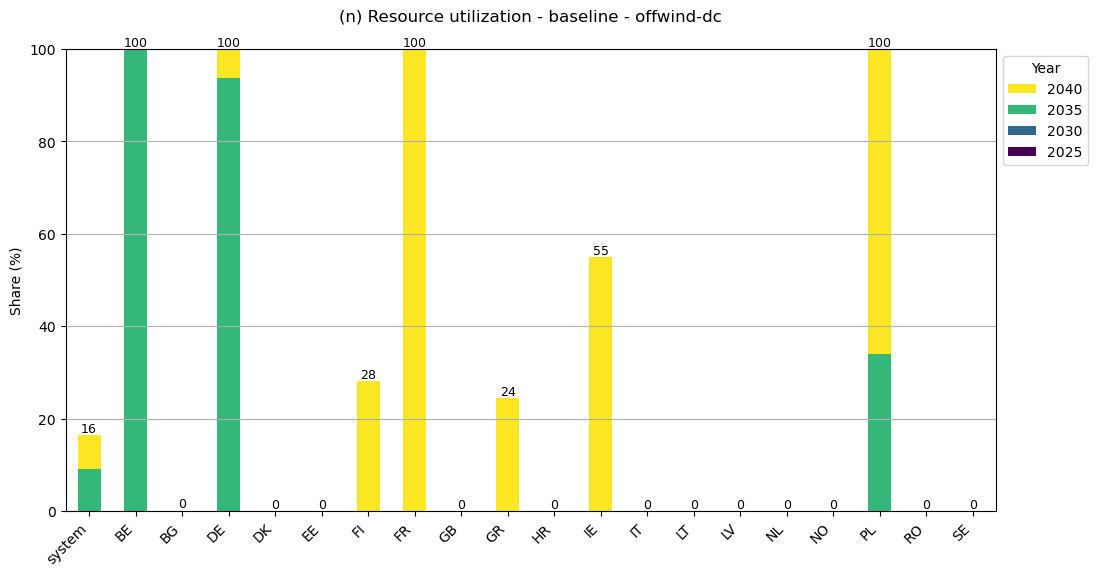

------------------> Analysing scenario energy-match-50


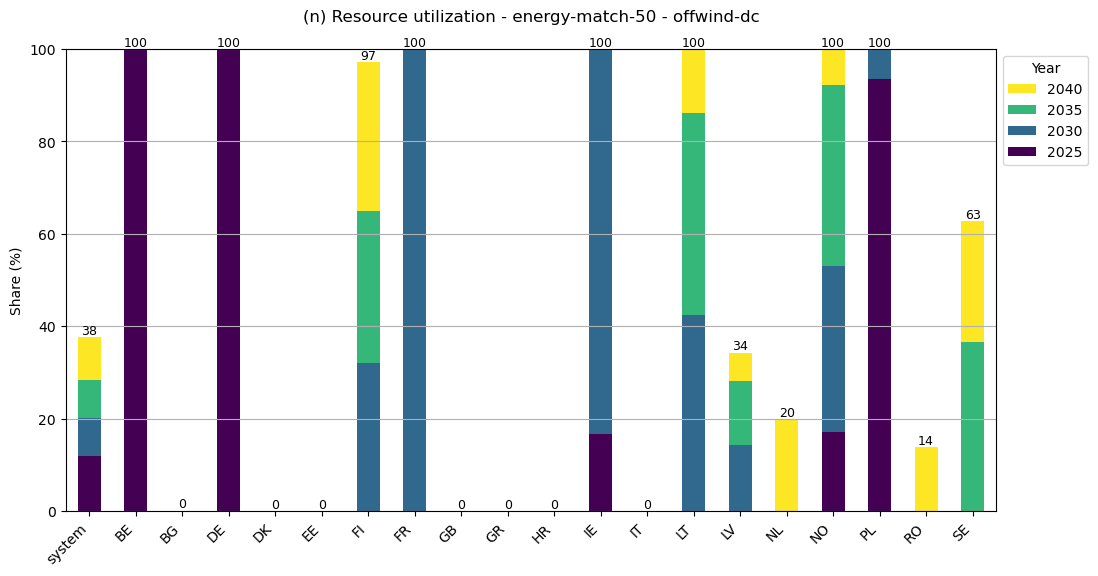

----------------------------------Analysing offwind-float
------------------> Analysing scenario baseline


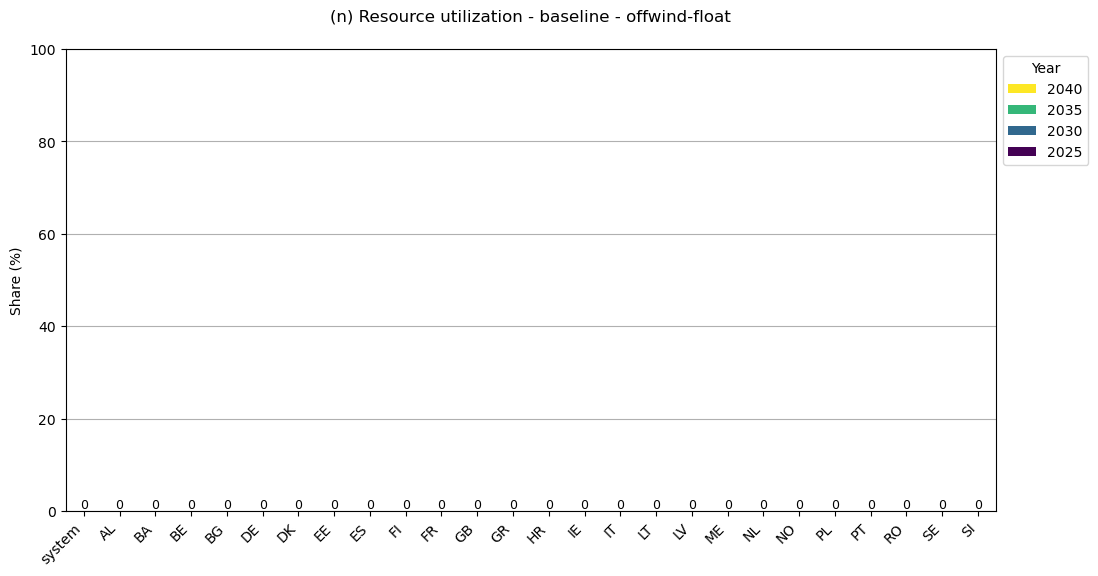

------------------> Analysing scenario energy-match-50


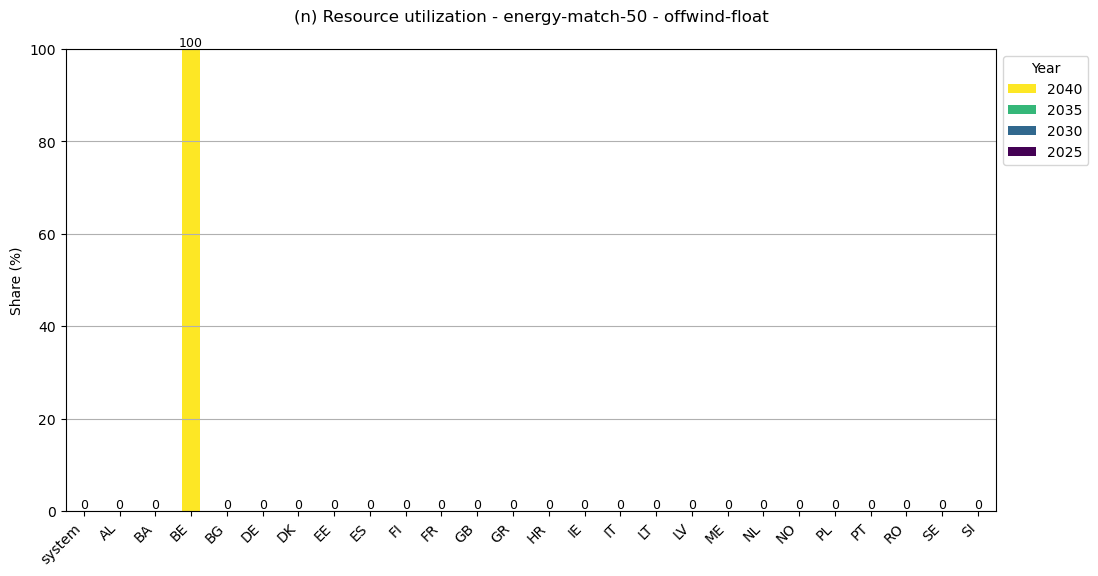

In [3]:
figures_to_generate = [
        'n', # derive_resource_utilization
]
fig_path_system = f"figures/resource_utilization"

# Combine all networks from different groups into a single DataFrame
df_networks = pd.concat([df for df in df_networks_all.values()], axis=0)
df_networks = df_networks[~df_networks.index.duplicated(keep='first')]

_ , _ = derive_all_figures(df_networks, country=None,
                           plot_fig=True, save_fig=True, fig_path=fig_path_system, save_csv=False,
                           figures=figures_to_generate,
                           figsize_bar_resource_utilization=figsize_bar_resource_utilization)
